In [15]:
!pip install -e .     
!pip install mudata
!pip install dill

Obtaining file:///Users/adamrempala/mofaflex
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mofaflex (pyproject.toml) ... done
  Created wheel for mofaflex: filename=mofaflex-0.1.0.post2.dev26+g337a4624e-py3-none-any.whl size=5228 sha256=678e1c15b2f9a0bb71048d691e9d0c72069a4f272963345edfab8caff136d1a4
  Stored in directory: /private/var/folders/dk/1q4z0mfn4h54c831qs59jvm80000gn/T/pip-ephem-wheel-cache-nig6dhh6/wheels/a0/75/82/983e214dcb8d64a4445691e600e6c1709a77a47f97f1859def
Successfully built mofaflex
  Attempting uninstall: mofaflex
    Found existing installation: mofaflex 0.1.0.post2.dev26+g337a4624e
    Uninstalling mofaflex-0.1.0.post2.dev26+g337a4624e:
      Successfully uninstalled mofaflex-0.1.0.post2.dev26+g337a4624e


In [2]:
!pip install mudata
!pip install mudatasets
!pip install muon
!pip install scanpy
!pip install plotnine

In [3]:
!source venv/bin/activate
!python -m pip install ipykernel
!python -m ipykernel install --user --name mofaflex --display-name "Python (mofaflex)"


Installed kernelspec mofaflex in /Users/adamrempala/Library/Jupyter/kernels/mofaflex


In [8]:

import mudata as md
import mudatasets as mds
import muon as mu
import mofaflex as mfl
import scanpy as sc
from plotnine import *

In [16]:
from tqdm import tqdm
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.optimize import linear_sum_assignment
import pickle
import dill

import sys
# load FACTM code
sys.path.append('factm')

# load code that produces artificial data
sys.path.append('simulations/data_generation')


In [17]:

with open('data/data_factm_names_2.pkl', "rb") as f:
    names = pickle.load(f)   # or dill.load if you switched
    D = [len(names[i]) for i in names.keys()]
    M = len(D)

print(D)

[61, 116, 3099, 189, 1000, 5, 11, 9, 9, 11, 9, 9, 15, 21, 15]


In [18]:
with open('data/data_factm_2.pkl', "rb") as f:
    data_2 = pickle.load(f)   # or dill.load if you switched
    N = data_2['M0'].shape[0]

for i in data_2.values():
    print(i[0][0])

-1.3119840205941693
-0.20649858943155783
-1.2249666469985578
0.059207076054441615
-1.081083261515401
1.7125269952396456
[3. 0. 2. 0. 0. 0. 2. 1. 0. 6. 0.]
[1. 0. 0. 2. 0. 1. 0. 0. 0.]
[4. 0. 0. 1. 0. 0. 0. 0. 0.]
[9. 0. 1. 0. 0. 0. 3. 0. 0. 3. 0.]
[16.  0.  0.  0.  1.  0.  0.  0.  0.]
[2. 1. 1. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 2. 0. 0. 0. 1. 3. 0. 0. 0.]
[0. 0. 8. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0.]


In [21]:
import numpy as np
import pandas as pd
from collections import Counter

def _extract_X(v):
    if isinstance(v, np.ndarray):
        X = v
    elif isinstance(v, (list, tuple)) and len(v) > 0 and isinstance(v[0], np.ndarray):
        X = v[0]
    else:
        raise TypeError(f"Don't know how to extract X from type={type(v)}; example={str(v)[:200]}")
    if X.ndim == 1:
        X = X[:, None]
    return X

def _is_structured_integerlike(X, tol=1e-6):
    if np.any(np.isnan(X)):
        return False
    nonneg = np.min(X) >= -tol
    integerlike = np.all(np.abs(X - np.round(X)) <= tol)
    return nonneg and integerlike

def _mod_sort_key(k):
    try:
        return int(k[1:])
    except:
        return k

def infer_consensus_N(data_2):
    """Pick N as the most common dimension across modalities (rows or cols)."""
    dims = []
    for k, v in data_2.items():
        X = _extract_X(v)
        dims.extend([X.shape[0], X.shape[1]])
    N, _ = Counter(dims).most_common(1)[0]
    return int(N)

def factm_to_mudata_flexible(
    data_2,
    names=None,
    filter_structured=True,
    structured_tol=1e-6,
    force_N=None,
    min_features=2,
):
    import anndata as ad
    import mudata as md

    # 1) Decide N
    N = int(force_N) if force_N is not None else infer_consensus_N(data_2)

    obs_names = pd.Index([f"cell_{i}" for i in range(N)], name="obs")

    adatas = {}
    dropped = {}

    for k in sorted(data_2.keys(), key=_mod_sort_key):
        X = _extract_X(data_2[k])

        # 2) Try to orient as (N x D)
        if X.shape[0] == N:
            X_view = X
            orient = "as_is"
        elif X.shape[1] == N:
            X_view = X.T
            orient = "transposed"
        else:
            dropped[k] = {
                "shape": X.shape,
                "reason": f"cannot match N={N} on rows or cols",
            }
            continue

        # 3) Drop degenerate feature counts
        if X_view.shape[1] < min_features:
            dropped[k] = {
                "shape": X_view.shape,
                "reason": f"too few features (<{min_features}) after orientation ({orient})",
            }
            continue

        # 4) Optionally filter structured/count modalities
        if filter_structured and _is_structured_integerlike(X_view, tol=structured_tol):
            dropped[k] = {
                "shape": X_view.shape,
                "reason": f"integer-like nonnegative (structured/count) ({orient})",
            }
            continue

        # 5) Feature names
        if names is not None:
            try:
                mi = int(k[1:])
                var_names = list(names[mi])
                # If feature-name length doesn't match, fall back to generated
                if len(var_names) != X_view.shape[1]:
                    var_names = [f"{k}_feat_{j}" for j in range(X_view.shape[1])]
            except Exception:
                var_names = [f"{k}_feat_{j}" for j in range(X_view.shape[1])]
        else:
            var_names = [f"{k}_feat_{j}" for j in range(X_view.shape[1])]

        adatas[k] = ad.AnnData(
            X=X_view.astype(np.float32, copy=False),
            obs=pd.DataFrame(index=obs_names),
            var=pd.DataFrame(index=pd.Index(var_names, name="var")),
        )

        # Store how we oriented it (handy for debugging)
        adatas[k].uns["factm_orientation"] = orient
        adatas[k].uns["factm_original_shape"] = tuple(X.shape)

    mu = md.MuData(adatas)
    return mu, dropped, N


In [22]:
mu, dropped, N = factm_to_mudata_flexible(data_2, names=names, filter_structured=True)

print("Chosen N =", N)
print("Kept modalities:", list(mu.mod.keys()))
print("Dropped summary:")
for k, info in dropped.items():
    print(k, info)


Chosen N = 192
Kept modalities: ['M0', 'M1', 'M2', 'M3', 'M4', 'M5']
Dropped summary:
M6 {'shape': (9998, 11), 'reason': 'cannot match N=192 on rows or cols'}
M7 {'shape': (9509, 9), 'reason': 'cannot match N=192 on rows or cols'}
M8 {'shape': (9905, 9), 'reason': 'cannot match N=192 on rows or cols'}
M9 {'shape': (5119, 11), 'reason': 'cannot match N=192 on rows or cols'}
M10 {'shape': (5089, 9), 'reason': 'cannot match N=192 on rows or cols'}
M11 {'shape': (1775, 9), 'reason': 'cannot match N=192 on rows or cols'}
M12 {'shape': (1067, 15), 'reason': 'cannot match N=192 on rows or cols'}
M13 {'shape': (1099, 21), 'reason': 'cannot match N=192 on rows or cols'}
M14 {'shape': (288, 15), 'reason': 'cannot match N=192 on rows or cols'}


In [27]:
mu

M0,bool,numpy.ndarray,1 columns
M1,bool,numpy.ndarray,1 columns
M2,bool,numpy.ndarray,1 columns
M3,bool,numpy.ndarray,1 columns
M4,bool,numpy.ndarray,1 columns
M5,bool,numpy.ndarray,1 columns
factm_orientation,str,5 elements,as_is
factm_original_shape,tuple,2 elements,"192,61..."
factm_orientation,str,5 elements,as_is
factm_original_shape,tuple,2 elements,"192,116..."
factm_orientation,str,5 elements,as_is


In [24]:
theme_set(theme_bw())
md.set_options(display_style="html", display_html_expand=0);

In [6]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
mdata = mds.load("pbmc3k_multiome")
mdata['rna']

■ File filtered_feature_bc_matrix.h5 from pbmc3k_multiome has been found at /Users/adamrempala/mudatasets/pbmc3k_multiome/filtered_feature_bc_matrix.h5
■ Checksum is validated (md5) for filtered_feature_bc_matrix.h5
■ Loading filtered_feature_bc_matrix.h5...


/Users/adamrempala/mofaflex/venv11/lib/python3.11/site-packages/mudatasets/core.py:203: UserWarning: Dataset is in the 10X .h5 format and can't be loaded as backed.
/Users/adamrempala/mofaflex/venv11/lib/python3.11/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
/Users/adamrempala/mofaflex/venv11/lib/python3.11/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Added `interval` annotation for features from /Users/adamrempala/mudatasets/pbmc3k_multiome/filtered_feature_bc_matrix.h5


/Users/adamrempala/mofaflex/venv11/lib/python3.11/site-packages/mudata/_core/mudata.py:947: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.


AnnData object with n_obs × n_vars = 2711 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

In [4]:
mdata = mds.load("pbmc3k_multiome")

■ File filtered_feature_bc_matrix.h5 from pbmc3k_multiome has been found at /Users/adamrempala/mudatasets/pbmc3k_multiome/filtered_feature_bc_matrix.h5
■ Checksum is validated (md5) for filtered_feature_bc_matrix.h5
■ Loading filtered_feature_bc_matrix.h5...


/Users/adamrempala/mofaflex/venv11/lib/python3.11/site-packages/mudatasets/core.py:203: UserWarning: Dataset is in the 10X .h5 format and can't be loaded as backed.
/Users/adamrempala/mofaflex/venv11/lib/python3.11/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
/Users/adamrempala/mofaflex/venv11/lib/python3.11/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Added `interval` annotation for features from /Users/adamrempala/mudatasets/pbmc3k_multiome/filtered_feature_bc_matrix.h5


/Users/adamrempala/mofaflex/venv11/lib/python3.11/site-packages/mudata/_core/mudata.py:947: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.


In [5]:
mdata.var_names_make_unique()
mdata

rna,bool,numpy.ndarray,1 columns
atac,bool,numpy.ndarray,1 columns


In [ ]:
rna = mu["rna"]
rna.var["mt"] = rna.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    rna, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)
mu.pp.filter_var(rna, "n_cells_by_counts", lambda x: x >= 3)
mu.pp.filter_obs(rna, "n_genes_by_counts", lambda x: (x >= 200) & (x < 5000))

mu.pp.filter_obs(rna, "total_counts", lambda x: x < 15000)
mu.pp.filter_obs(rna, "pct_counts_mt", lambda x: x < 20)

atac = mdata.mod["atac"]
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
mu.pp.filter_var(atac, "n_cells_by_counts", lambda x: x >= 10)
mu.pp.filter_obs(atac, "n_genes_by_counts", lambda x: (x >= 2000) & (x <= 15000))
mu.pp.filter_obs(atac, "total_counts", lambda x: (x >= 4000) & (x <= 40000))

In [7]:
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, min_mean=0.02, max_mean=4, min_disp=0.5)

mu.atac.pp.tfidf(atac, scale_factor=1e4)
sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
sc.pp.log1p(atac)
sc.pp.highly_variable_genes(atac, min_mean=0.05, max_mean=1.5, min_disp=0.5)

mdata.update()

In [8]:
mdata

MuData object with n_obs × n_vars = 2695 × 119335
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
  2 modalities
    rna:	2636 x 21256
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg'
    atac:	2450 x 98079
      obs:	'n_genes_by_counts', 'total_counts', 'n_counts'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg'

WARNING	Device cuda is not available. Using default device: cpu


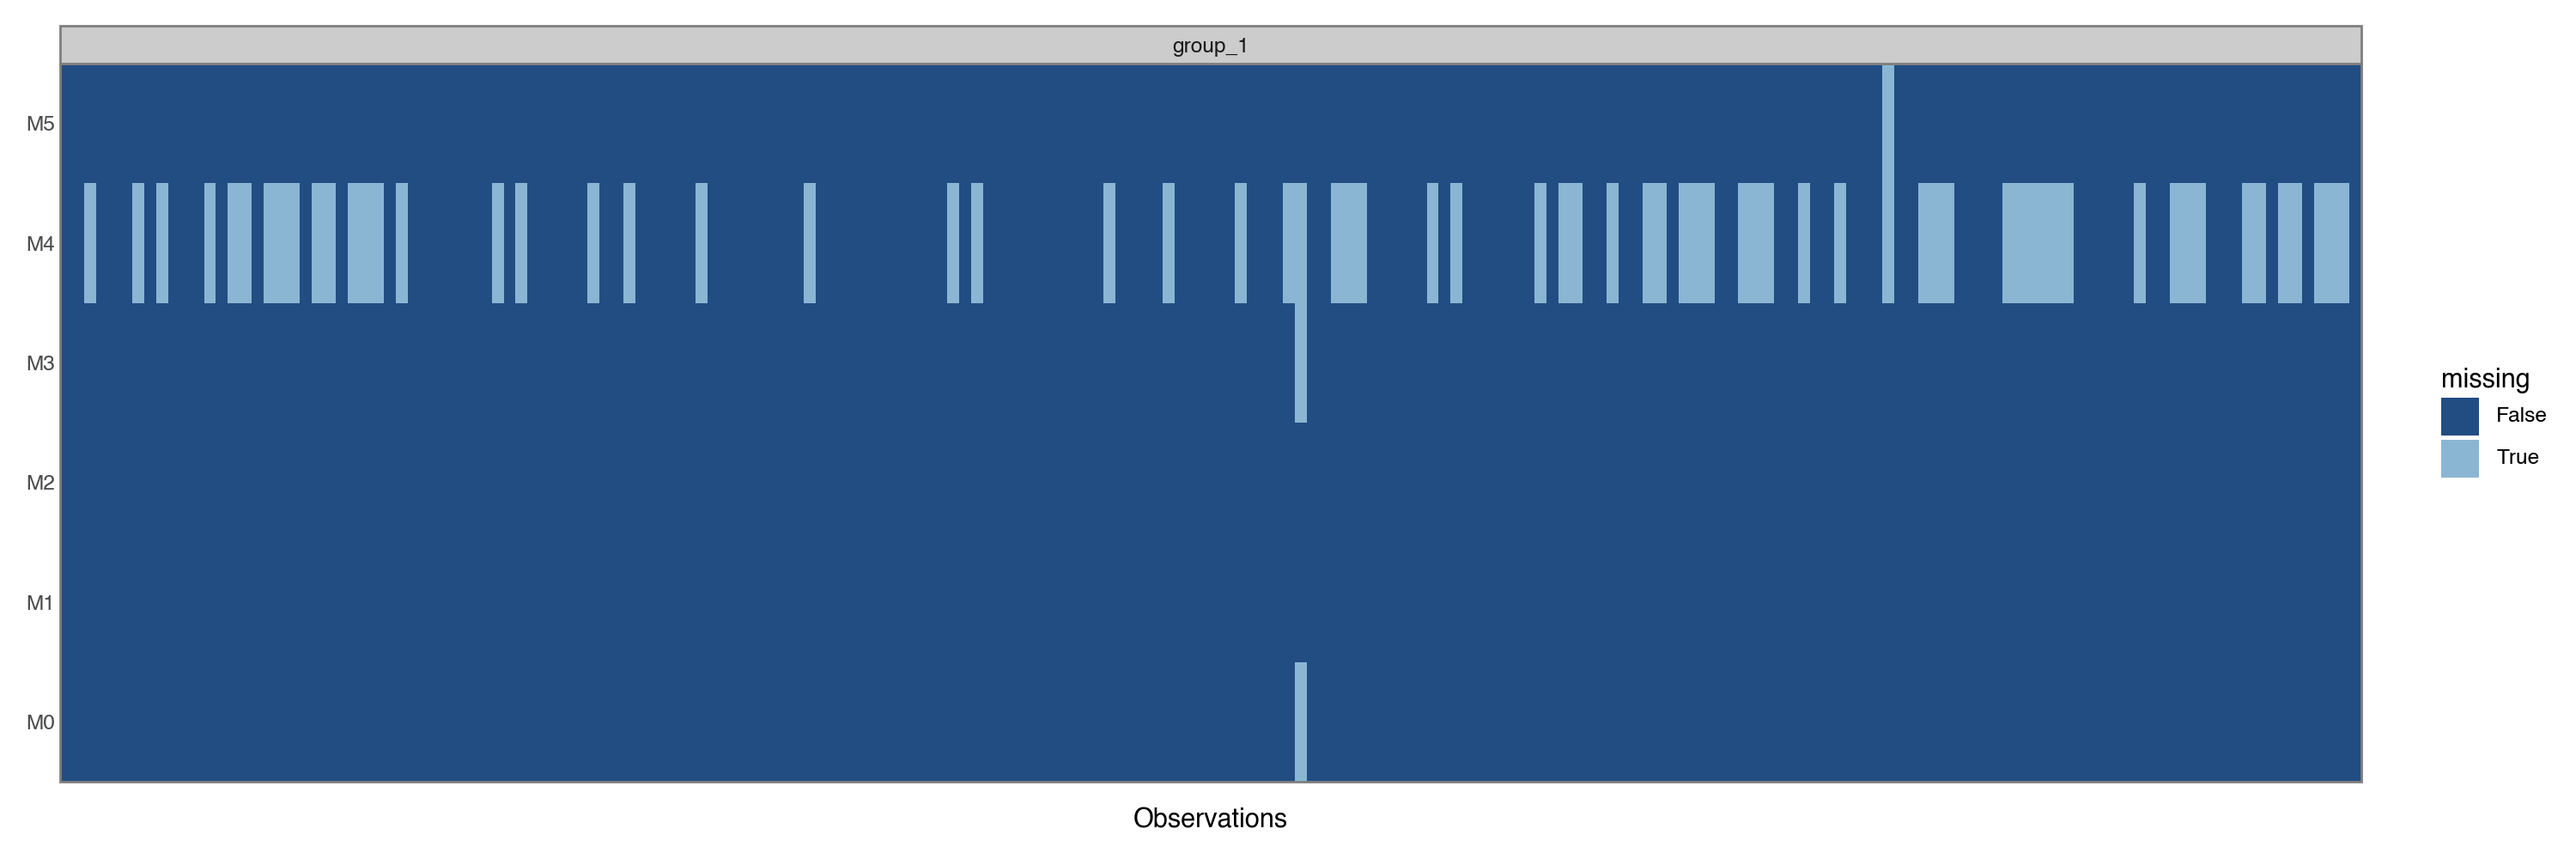

WARNING	Could not import dask. Data arrays may be copied, resulting in high memory usage.
/Users/adamrempala/mofaflex/src/mofaflex/_core/utils.py:165: RuntimeWarning: Mean of empty slice
INFO	Initializing factors using `random` method...
 28%|██▊       | 2811/10000 [01:22<03:30, 34.21epochs/s, Loss=3.07e+3]
INFO	Saving results to mofaflex_20260114_120622.h5...


In [28]:
model = mfl.MOFAFLEX(
    mu,
    mfl.ModelOptions(n_factors=15, likelihoods="Normal"),
    mfl.TrainingOptions(batch_size=1000, seed=42),
)

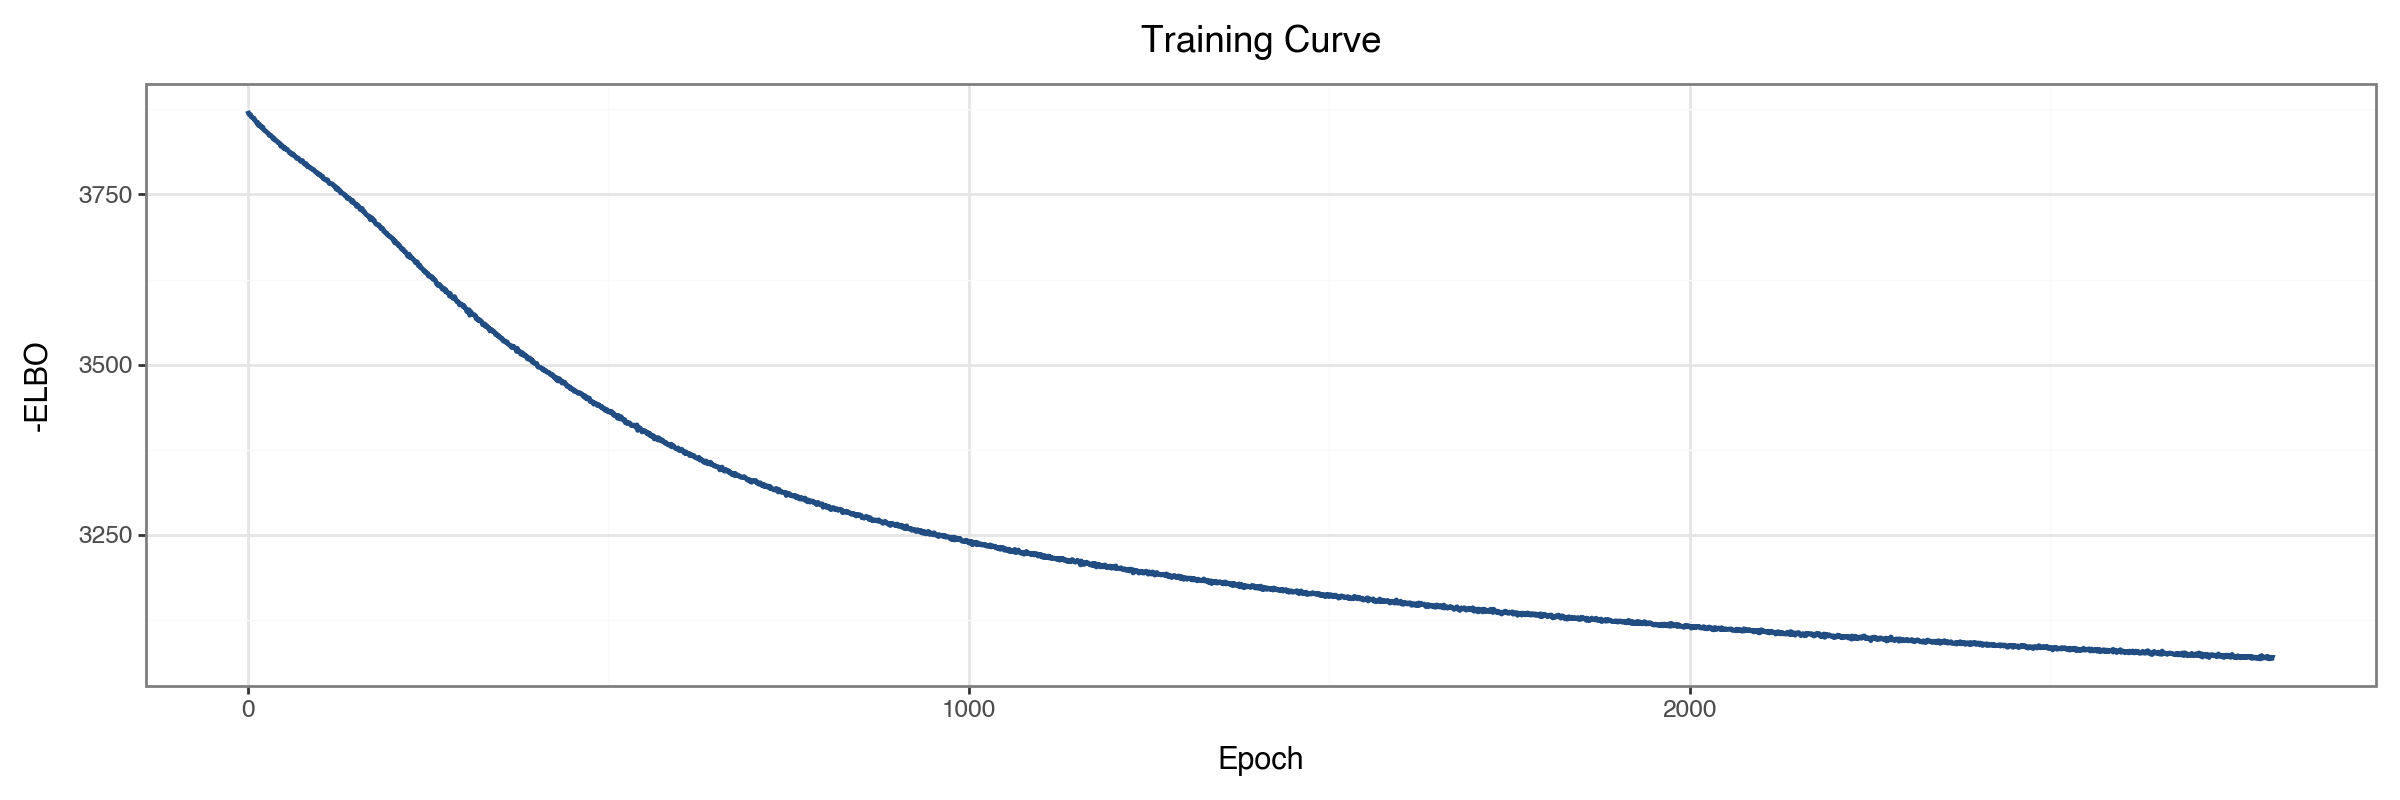

In [29]:
mfl.pl.training_curve(model)

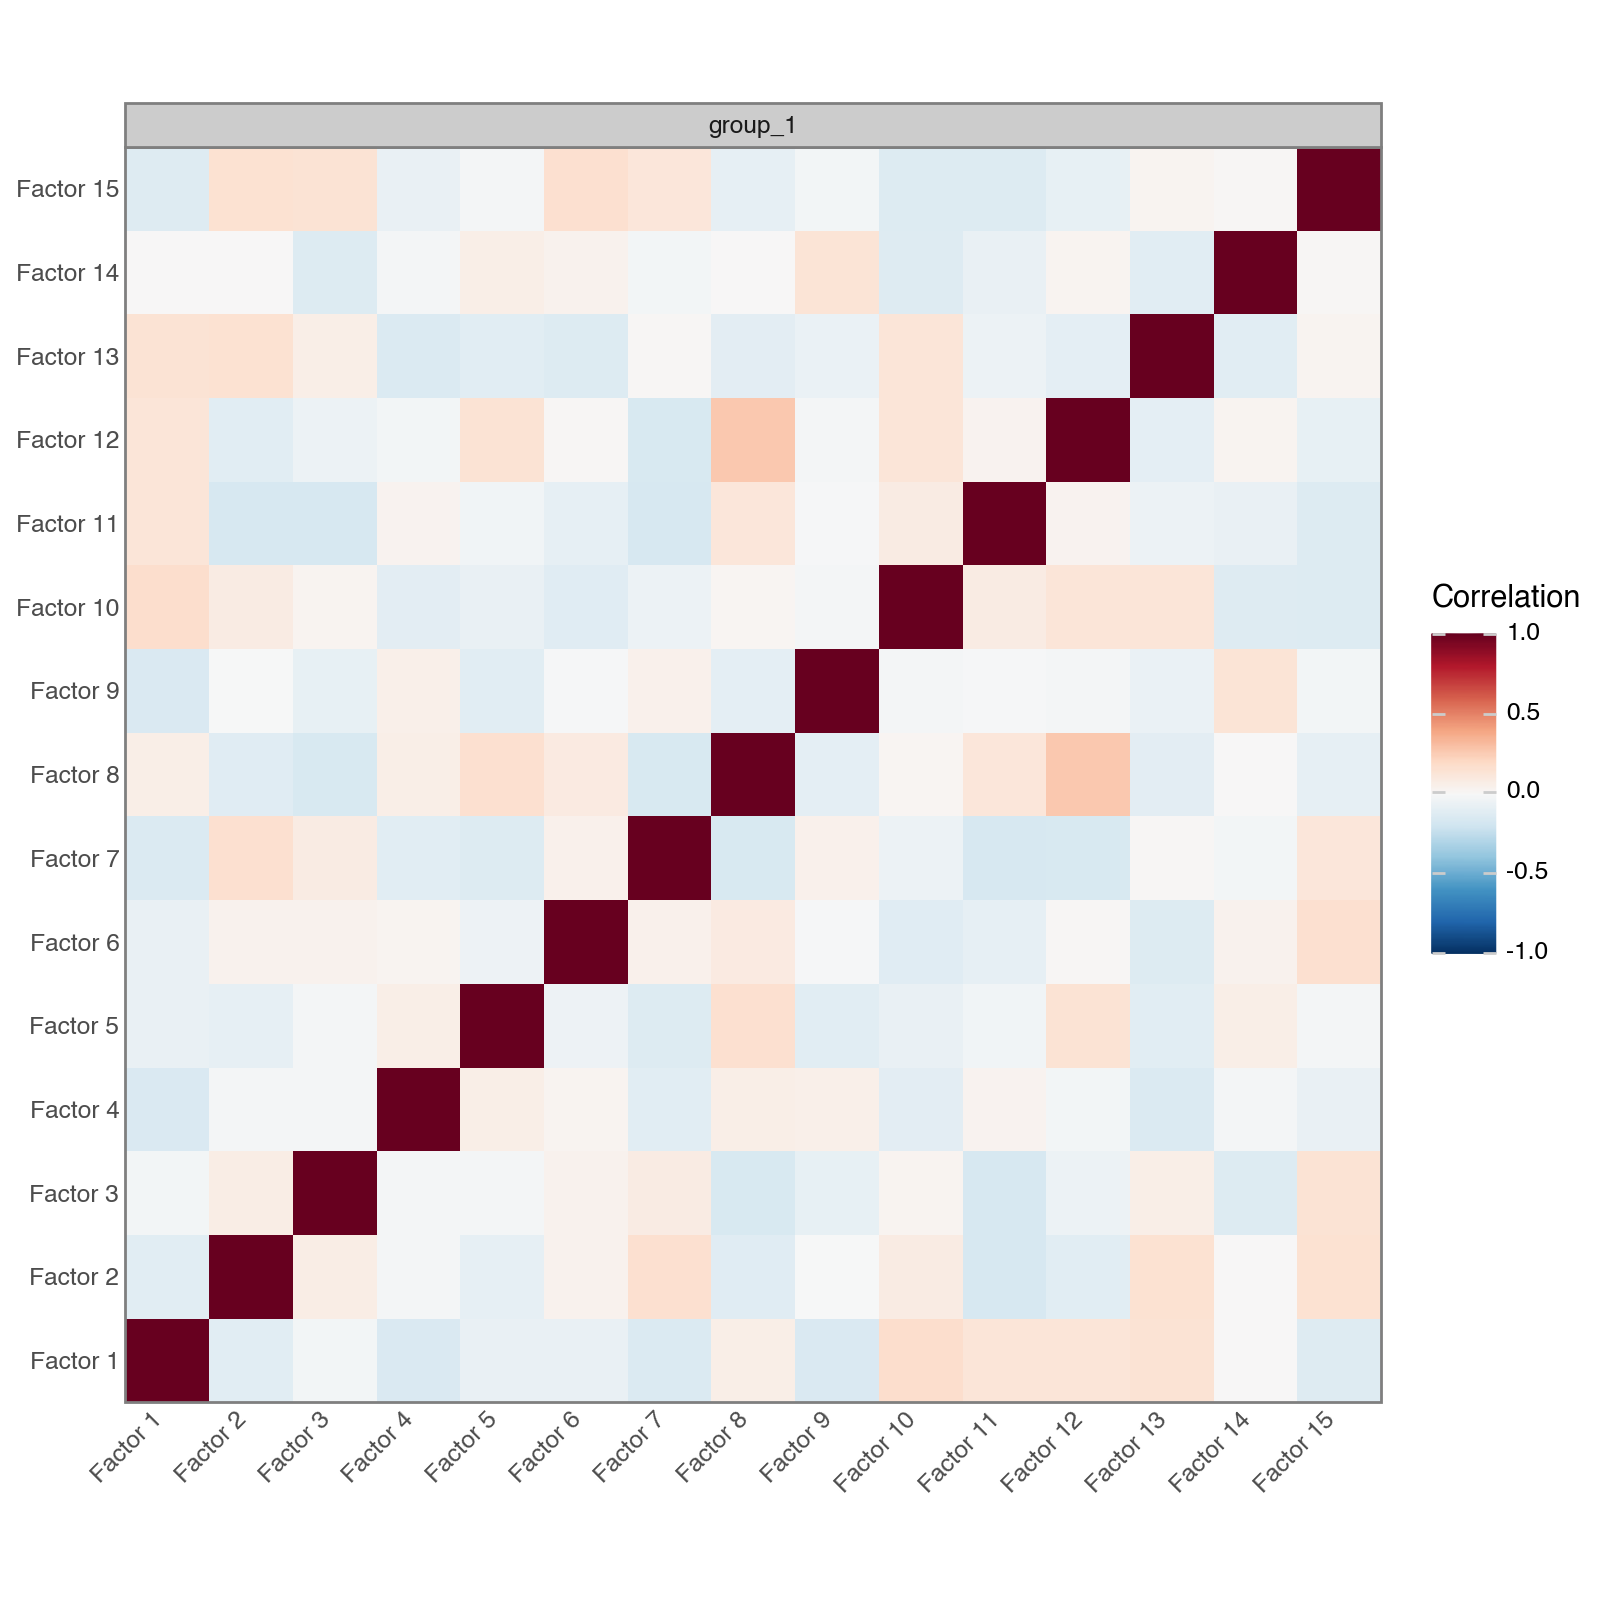

In [30]:
mfl.pl.factor_correlation(model)

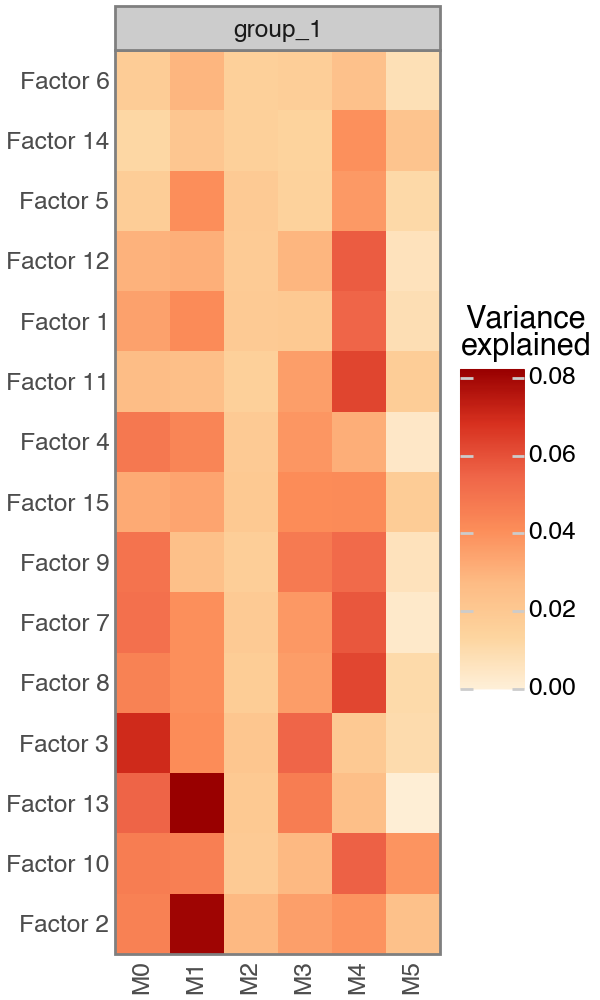

In [31]:
mfl.pl.variance_explained(model)

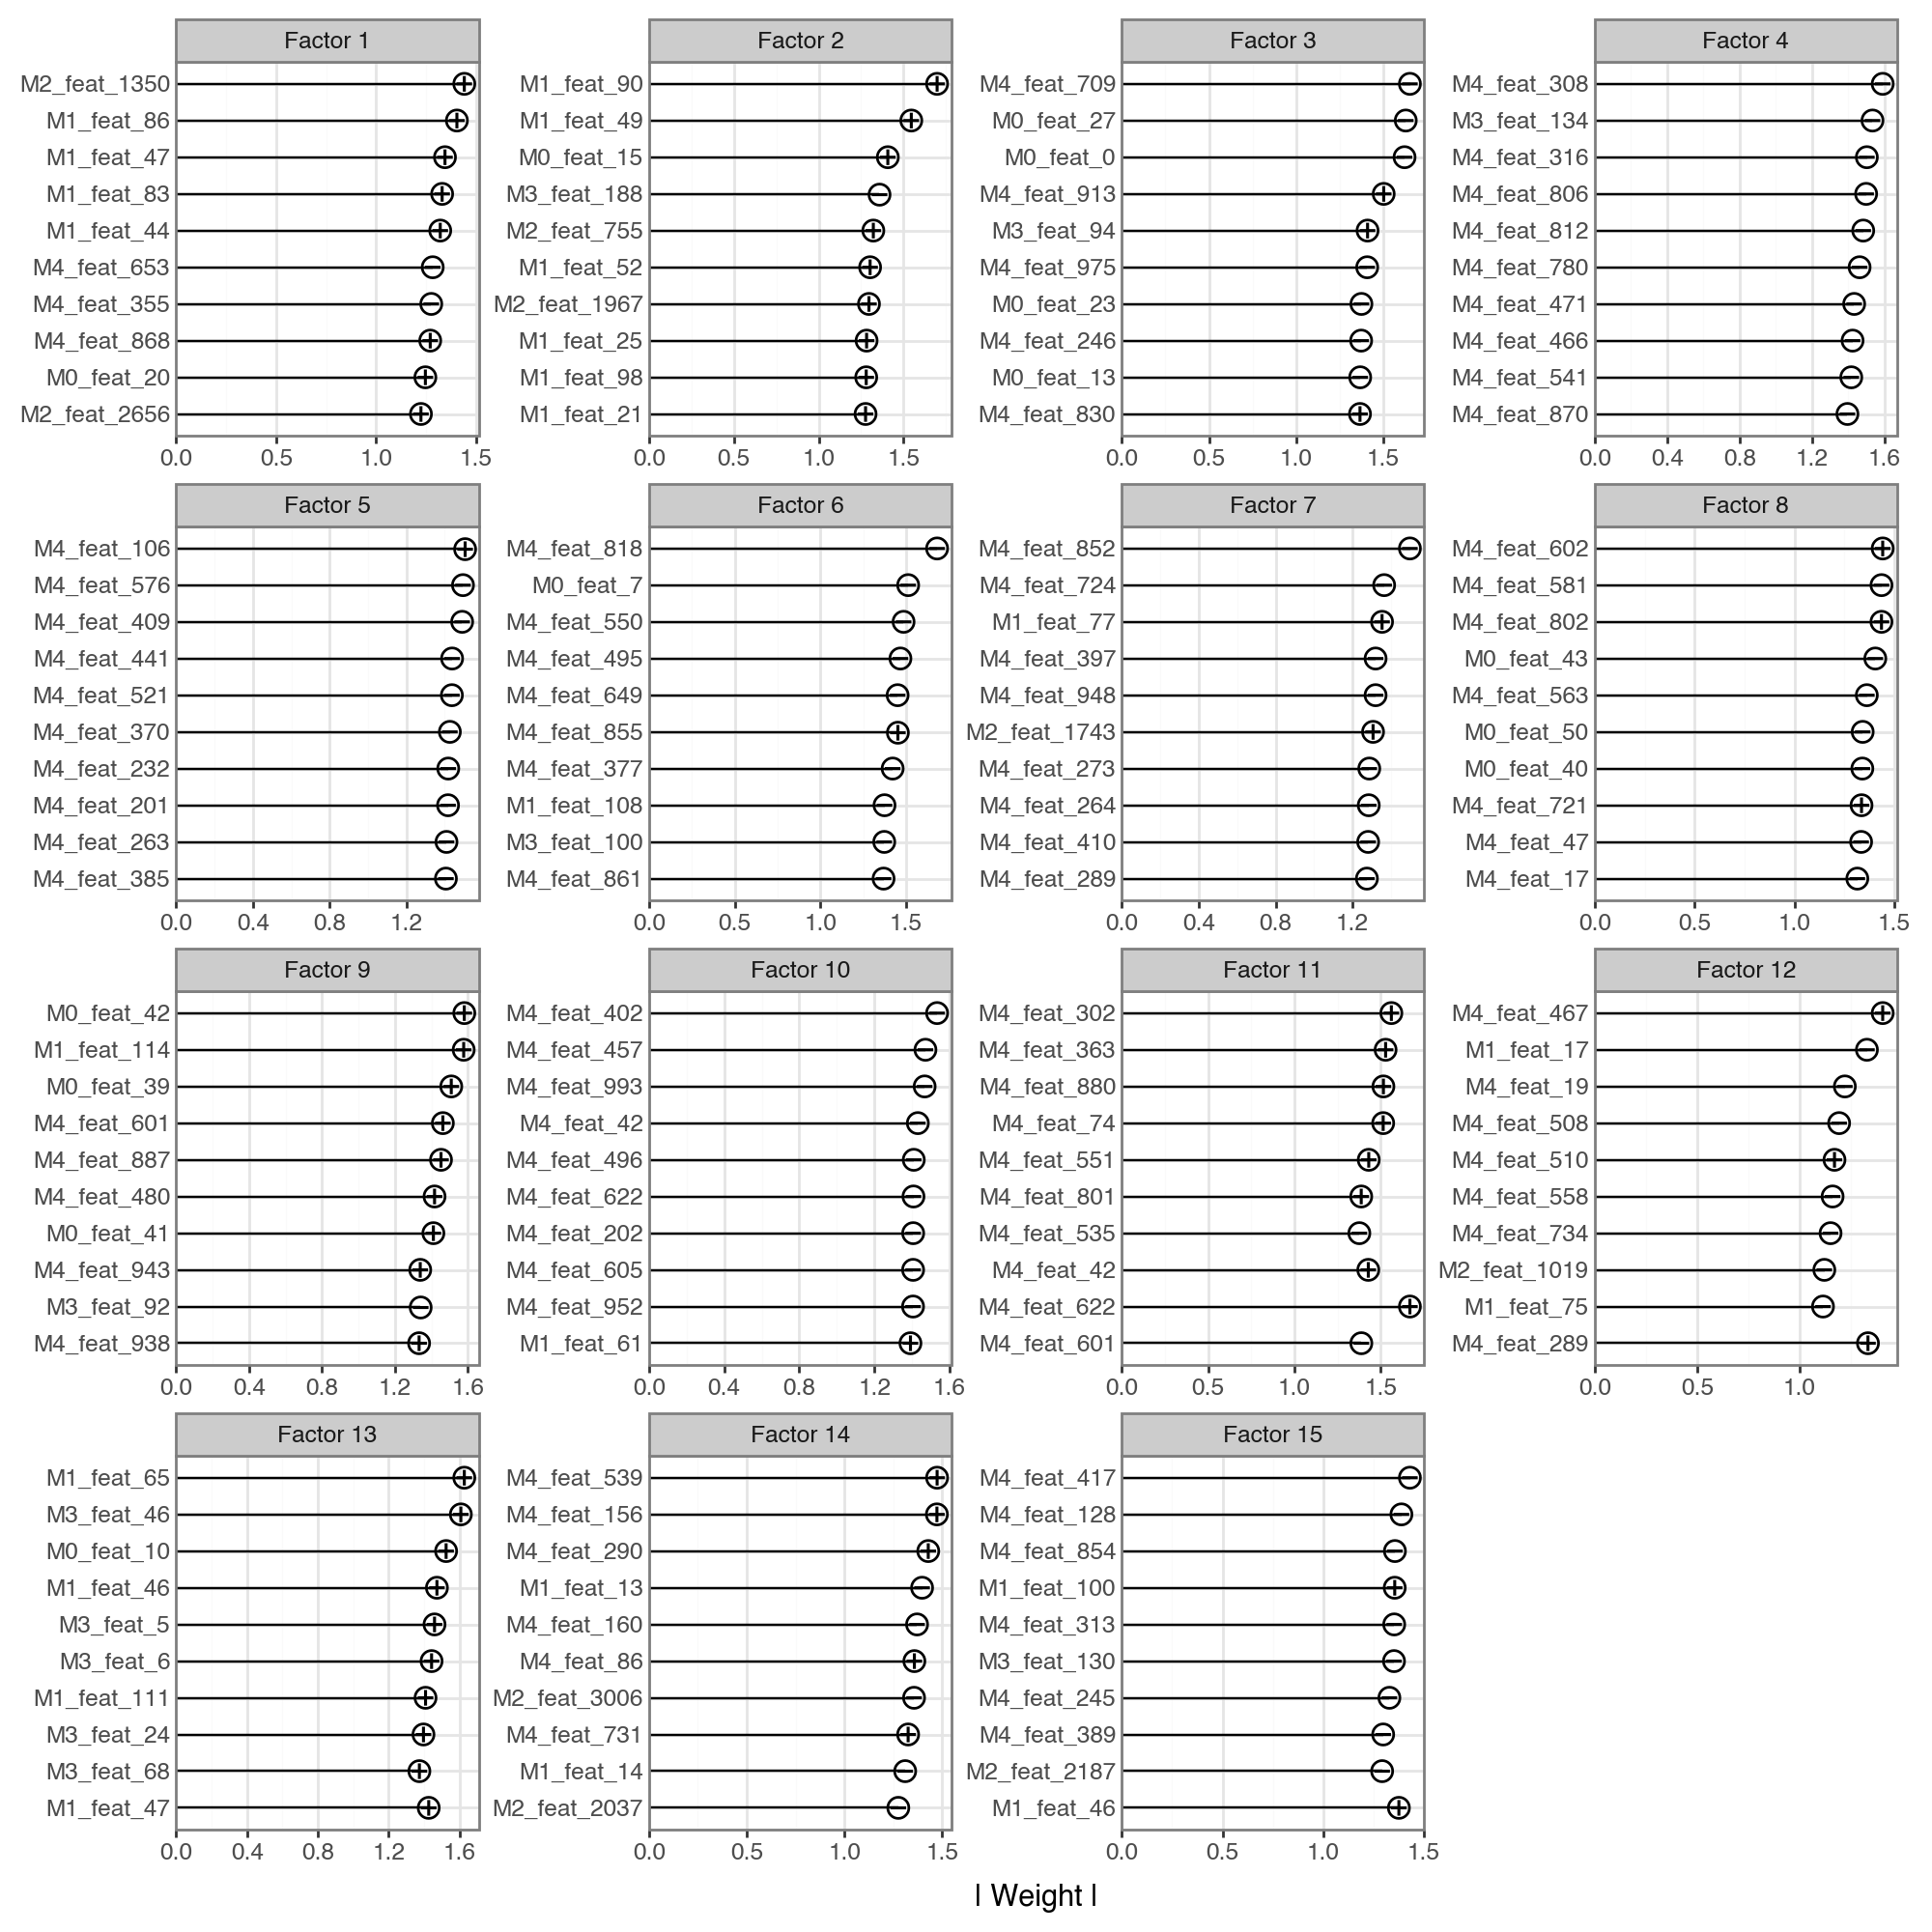

In [32]:
mfl.pl.top_weights(model, figsize=(10, 10))

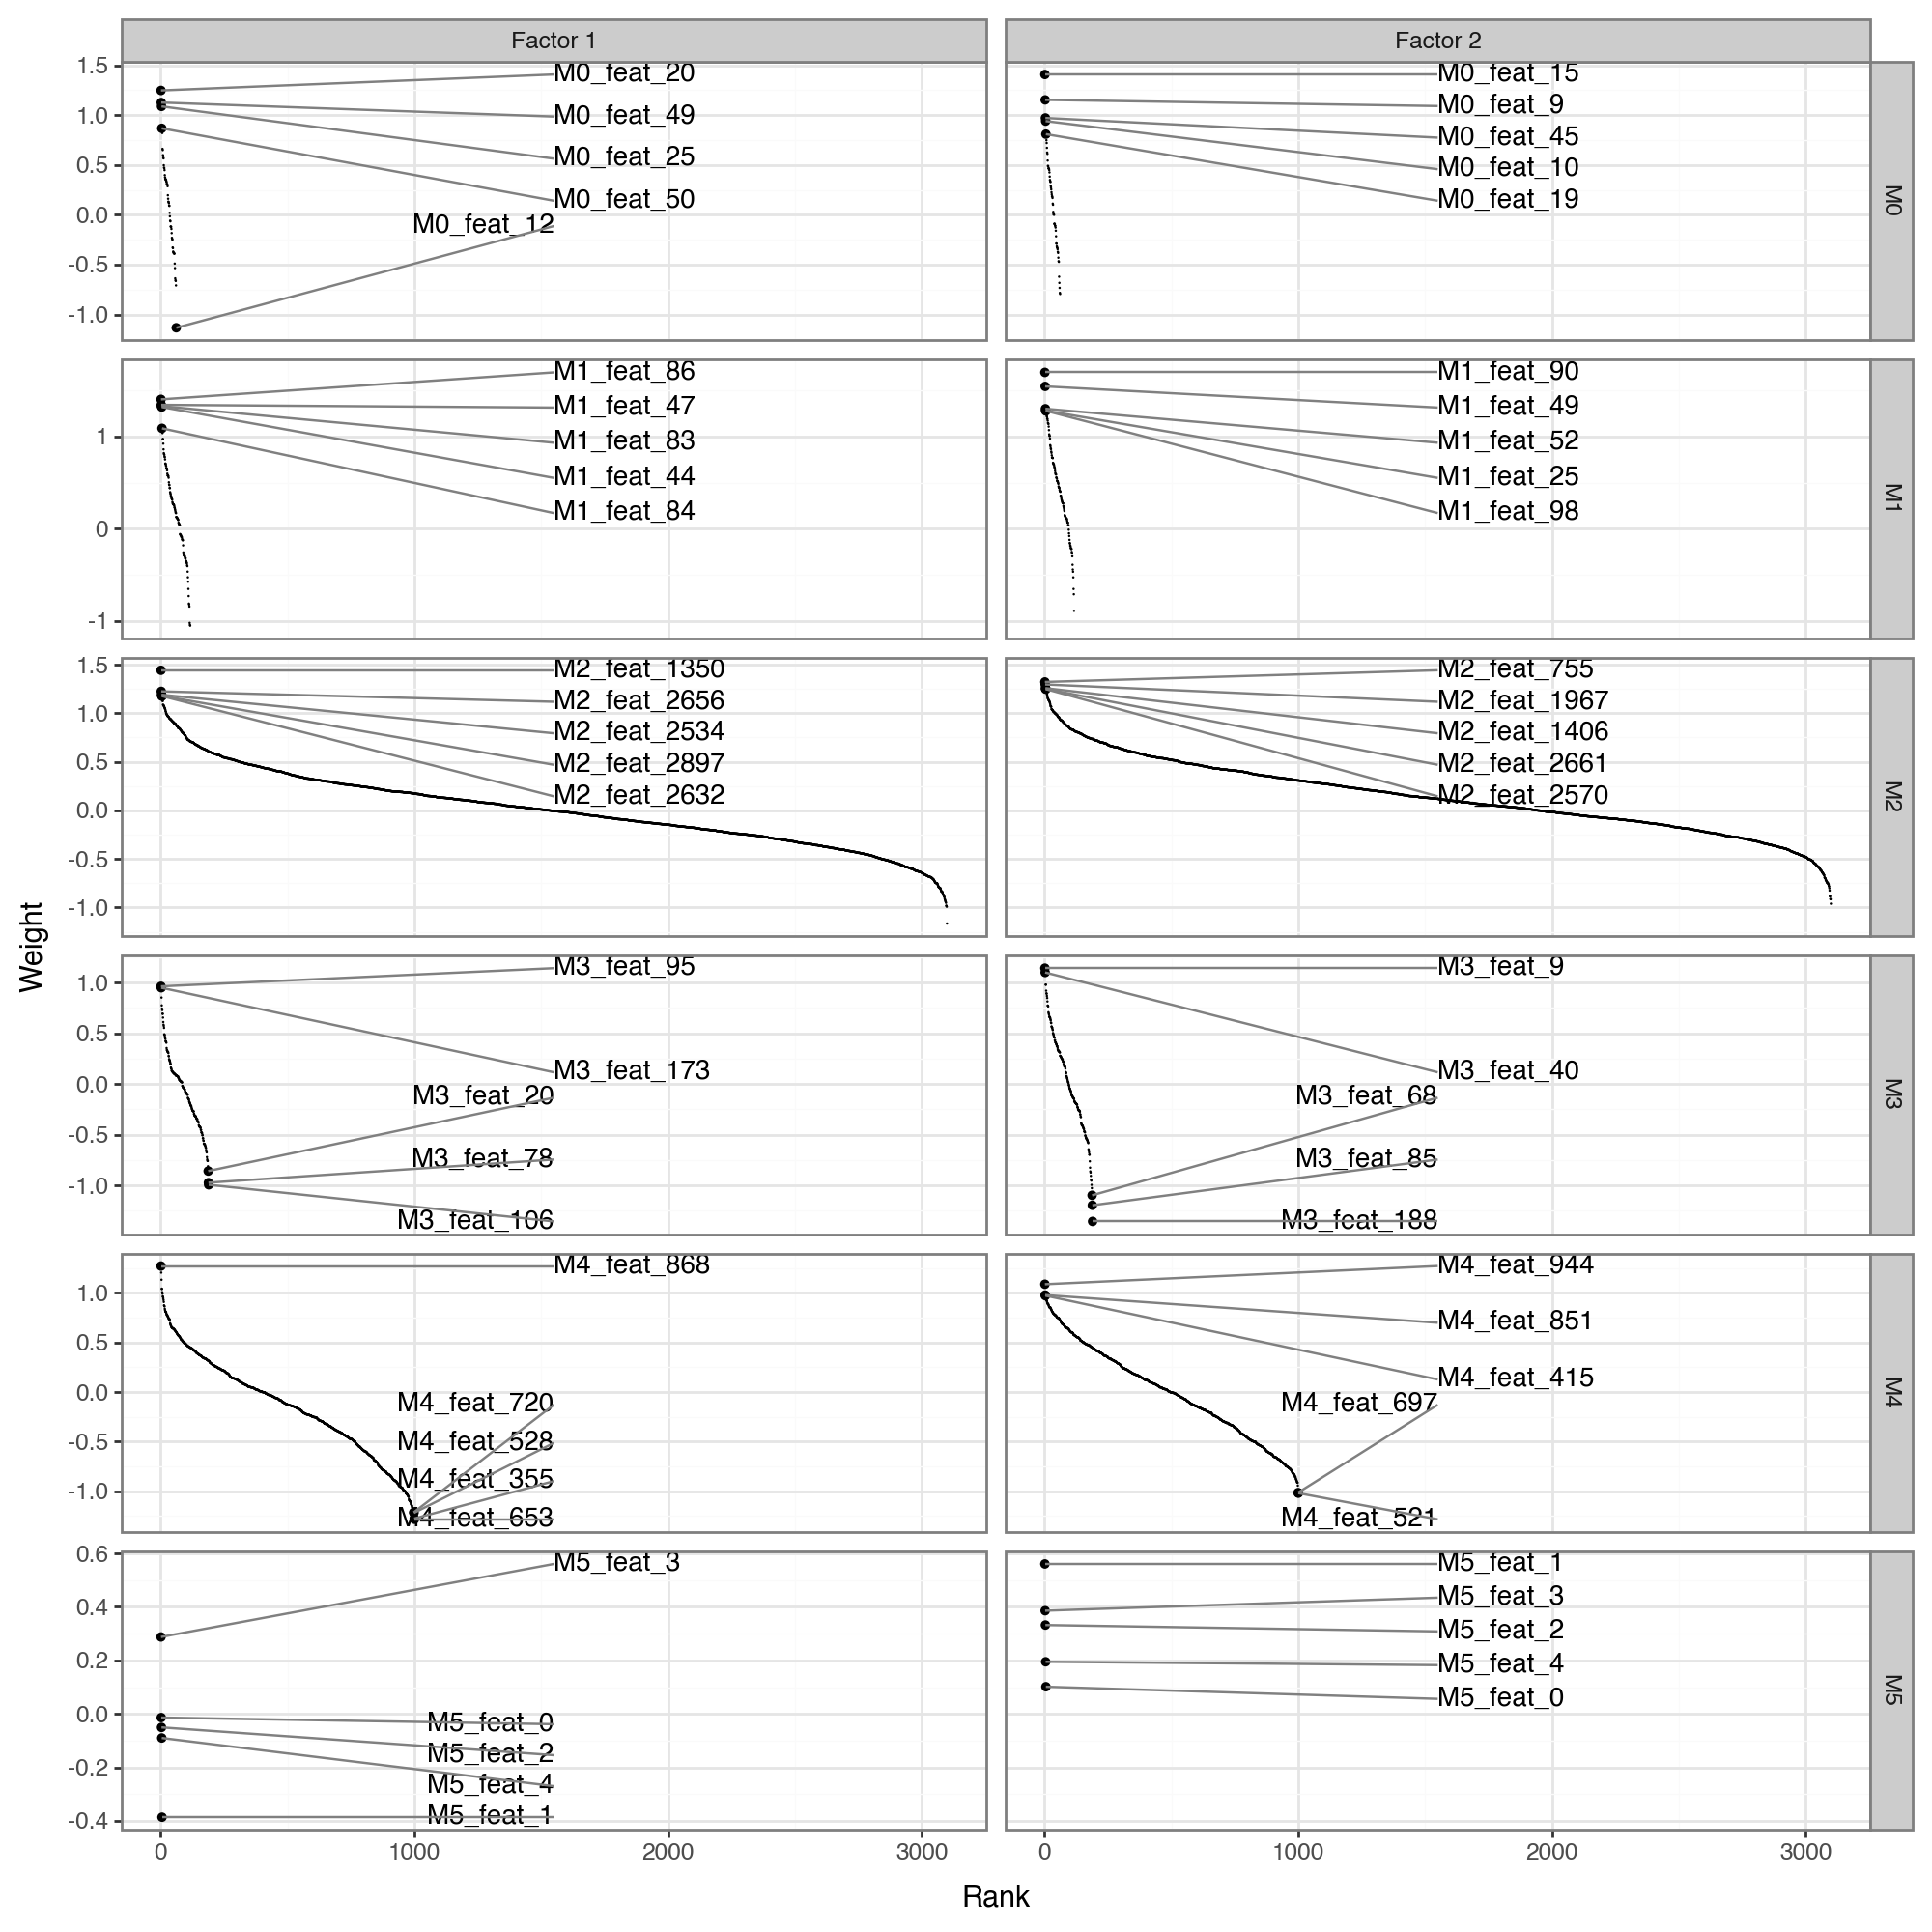

In [44]:
mfl.pl.weights(model, factors=(1, 2), n_features=5, figsize=(10, 10))

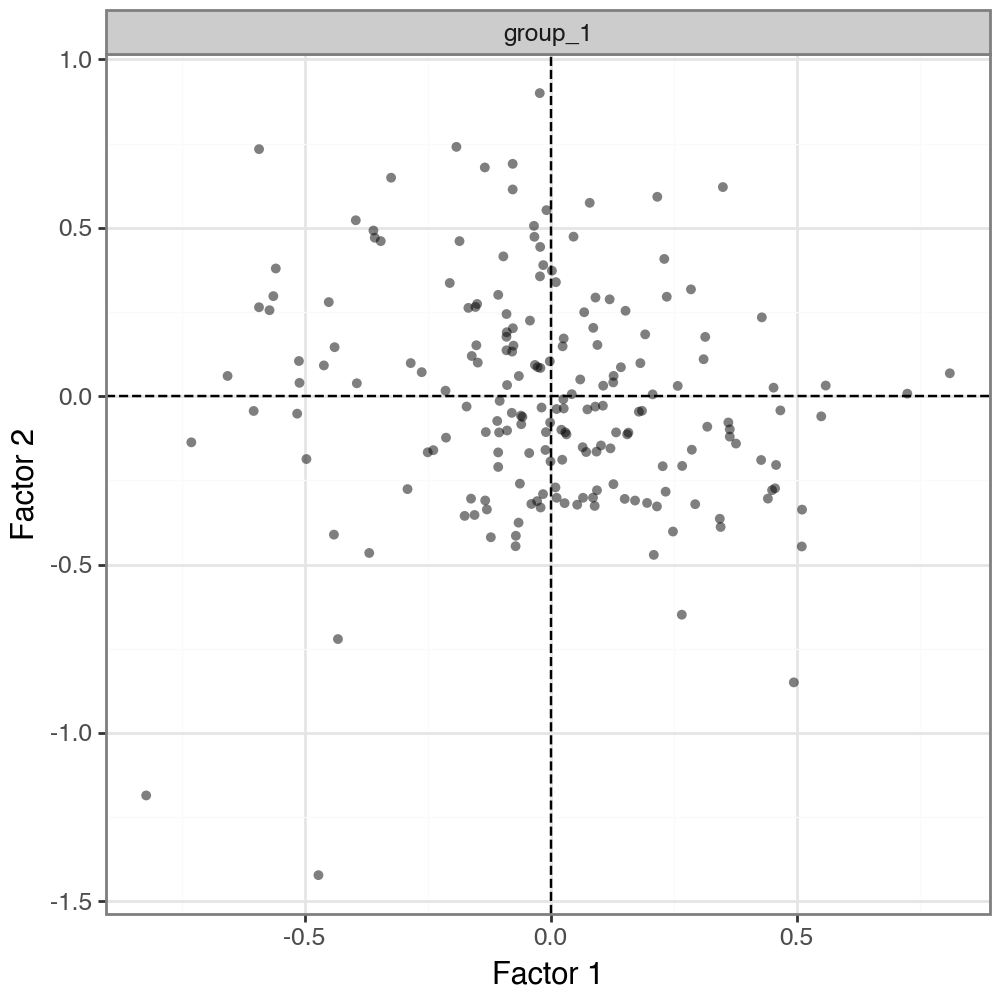

In [38]:
mfl.pl.factors_scatter(model, 1, 2, alpha=0.5)

In [39]:
weights = model.get_weights()
factors = model.get_factors()

weights["M0"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
M0_feat_0,-0.534848,-0.216000,-1.623276,0.411291,0.638890,-0.067078,-0.611699,-0.642549,0.373472,-0.023324,-0.582905,-0.911366,-0.165917,-0.125696,-0.100006
M0_feat_1,-0.380194,0.544082,0.073929,0.585290,0.302122,-0.046406,0.100384,-0.251465,-0.170498,-0.820143,-1.058697,-0.945571,0.787797,0.056805,0.394028
M0_feat_2,0.597820,-0.620997,0.673087,0.013131,0.046646,-0.629552,-0.712655,0.314086,-0.099259,-0.292115,-0.244682,0.169080,0.575448,-0.023947,-0.681199
M0_feat_3,0.127355,0.100383,-0.338330,-0.612144,0.236829,-0.222095,-0.355030,0.323505,-0.427997,-0.419239,-0.121131,0.597745,1.195406,-0.080610,-0.691707
M0_feat_4,-0.369100,-0.328757,-1.099698,1.008572,0.055855,0.389827,-0.662328,-0.737874,0.241618,0.518153,0.045628,-0.223718,-0.359556,0.247479,-0.049190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
M0_feat_56,-0.058852,-0.090422,0.020113,-0.090051,-0.084434,-0.176859,0.453299,-0.021653,-0.261705,-0.195011,-0.307831,-0.019464,0.287045,-0.064600,0.705741
M0_feat_57,-0.489815,-0.111176,-0.473375,-0.455891,0.049516,0.651868,-0.002349,-0.504682,0.145862,-0.265385,-0.999288,0.494790,0.259313,0.449100,0.273774
M0_feat_58,-0.121587,0.719934,-0.173851,0.232585,0.058793,0.208704,-0.082008,0.248444,-0.549226,-0.738703,0.220549,-0.504307,-0.011382,-0.126435,0.092341
M0_feat_59,-0.242350,-0.472059,0.246997,-0.069674,0.407063,0.200520,0.195157,0.129905,-0.509197,-0.650138,-0.810652,-0.302471,-0.164616,-0.384740,-0.192573


In [40]:
weights["M1"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
M1_feat_0,0.039506,-0.120877,0.057385,-0.031401,-0.645835,-0.545921,-0.155979,-0.183583,0.291365,0.236726,1.094907,0.235160,0.057289,0.424251,0.649649
M1_feat_1,-0.823972,0.709129,-0.944682,0.197224,0.646549,0.953302,0.072911,0.562621,-0.211978,-0.402142,-0.398793,-0.821513,0.519068,0.076868,-0.321708
M1_feat_2,0.803785,1.173900,0.205659,-0.904642,-1.004081,0.605146,0.087130,-0.320837,-0.109735,0.926845,0.080580,0.416605,0.829003,-0.154055,-0.121687
M1_feat_3,0.576892,0.134155,-0.335467,-0.736516,-0.468884,0.076928,-0.272818,-0.816210,0.370677,0.192860,0.457445,-0.500831,0.440092,-0.246086,0.294978
M1_feat_4,0.169040,0.400757,0.265979,0.395990,0.188079,-0.376163,0.153874,-0.025066,0.247544,1.039158,-0.252595,0.382827,-0.010583,-0.384809,-0.060767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
M1_feat_111,-0.813118,0.191776,-0.993522,0.679785,0.438801,0.593739,-0.287762,0.508657,-0.866458,-0.422695,-0.365277,-0.495562,1.407620,0.207014,-0.549959
M1_feat_112,-0.320386,-0.219889,0.382919,-0.452920,0.780415,0.379632,-0.044615,-0.752888,0.122193,0.632649,0.896733,-0.806392,0.674218,-0.547097,-0.005332
M1_feat_113,0.820969,0.036841,0.650329,-1.071179,-0.128438,0.254160,-0.785691,-0.373143,0.079816,0.249031,0.077229,-0.316897,1.072656,0.360600,-0.218583
M1_feat_114,0.047193,0.420393,-0.885177,0.661745,-0.514619,-0.311611,0.233856,0.674121,1.577098,0.241688,0.516862,0.312827,0.469419,0.476093,-0.057442


In [41]:
factors["group_1"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
cell_0,-0.033767,0.505944,0.494927,0.276095,-0.374619,0.428018,-0.044949,-0.124934,-0.059136,0.407660,-0.121725,0.352274,0.005391,-0.336111,-0.190183
cell_1,-0.020342,-0.330591,-0.027272,0.470006,0.423415,0.161601,-0.054062,-0.055519,0.508278,-0.362168,0.406408,0.109996,0.487961,-0.391505,-0.486241
cell_2,-0.563444,0.297158,0.022039,0.496596,0.432259,0.372797,-0.147470,-0.229228,0.628106,-0.103845,-0.239846,-0.090747,-0.699613,0.257372,0.347606
cell_3,0.453089,0.025340,-0.267221,0.310926,-0.244637,0.530715,-0.028991,-0.464570,0.142768,0.177102,0.118773,-0.088883,-0.114272,-0.495237,0.171440
cell_4,-0.106499,-0.210140,-0.005061,0.162829,-0.088927,-0.148578,0.074860,0.129980,0.351908,-0.231326,0.317794,0.048651,-0.040137,0.389981,-0.072622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cell_187,-0.001650,0.103663,0.253563,0.012796,-0.148471,-0.072208,-0.074553,0.235420,0.140741,0.197958,0.227585,0.200726,0.068825,0.349040,-0.129676
cell_188,0.345553,-0.388348,-0.141456,-0.085203,-0.149335,-0.034780,-0.130460,0.236651,0.059368,0.068599,0.064206,0.161005,0.119592,0.089310,0.005324
cell_189,0.549999,-0.059924,0.021831,-0.141987,0.625772,-0.051651,-0.308262,0.431416,-0.080994,0.113734,-0.018082,0.273668,-0.010027,0.242807,0.092666
cell_190,0.343813,-0.364013,-0.073868,0.064515,-0.469713,0.065298,-0.248687,-0.780936,-0.630239,-0.079138,0.534245,-0.746083,-0.420865,0.612934,-0.202230
